In [ ]:
import os
import numpy as np
import scipy
from scipy.io import wavfile
import scipy.fftpack as fft
from scipy.signal import get_window
import IPython.display as ipd
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
ipd.Audio('download.wav')

In [ ]:
sample_rate, audio = wavfile.read('download.wav')
print("Sample rate: {0}Hz".format(sample_rate))
print("Audio duration: {0}s".format(len(audio) / sample_rate))

Sample rate: 44100Hz
Audio duration: 6.12s


Notice that the sample rate is 44.1kHz which is the standart sampling rate for audio files. This number is not a coincidence. Acording to Nyquist, that sampling rate of 44.1kHz give us band-width of 22.05kHz. The 0Hz to 22.05kHz zone is called the first Nyquist zone, 22.05kHz to 44.1kHz is the second Nyquist zone and so on.

In [ ]:
def normalize_audio(audio):
    audio = audio / np.max(np.abs(audio))
    return audio

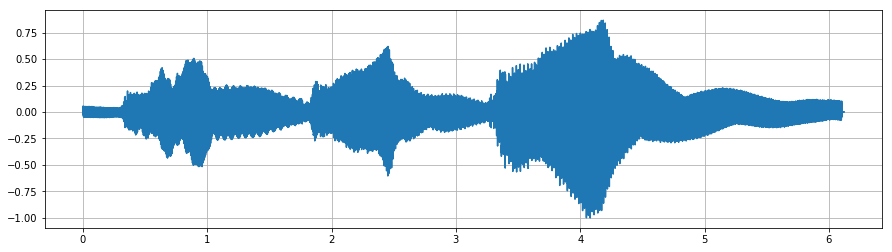

In [ ]:
audio = normalize_audio(audio)
plt.figure(figsize=(15,4))
plt.plot(np.linspace(0, len(audio) / sample_rate, num=len(audio)), audio)
plt.grid(True)

**Audio Framing**

Because audio is a non stationary process, the FFT will produce distortions. To overcome this we can assume that the audio is a stationary process for a short periods of time. Because of that we devide the signal into short frames. Each audio frame will be the same size as the FFT. Also we want the frames to overlap. We do that so that the frames will have some correlation between them and because we loose the information on the edges of each frame after applying a window function.

**audio = np.pad(audio, int(FFT_size / 2), mode='reflect')**

What this padding does is adding reflected edges of the signal to the edges of the signal with the length of half the FFT size. For example, if we have a vector [1,2,3,4,5,6] then after this padding of length 2 it becomes [2,1,1,2,3,4,5,6,6,5].

If we will not add padding to the signal, the window function will distort and eliminate the edges of the signal. Remember that the audio signals are non stationary and the information changes all the time so the edges of the signal holds unique information. By padding the signal, we preserve the information on the edges of the signal because they will go through the window function around its maximum. There are several ways to pad the signal but practically mode='reflect' usually works the best.

Now why we pad only once and not every frame? This is because the frames should overlap so the information on the edges of each frame get preserved in several frames (at least 2).

In [ ]:
def frame_audio(audio, FFT_size=2048, hop_size=10, sample_rate=44100):
    # hop_size in ms

    audio = np.pad(audio, int(FFT_size / 2), mode='reflect')
    frame_len = np.round(sample_rate * hop_size / 1000).astype(int)
    frame_num = int((len(audio) - FFT_size) / frame_len) + 1
    frames = np.zeros((frame_num,FFT_size))

    for n in range(frame_num):

        frames[n] = audio[n*frame_len:n*frame_len+FFT_size]

    return frames

In [ ]:
hop_size = 15 #ms
FFT_size = 2048

audio_framed = frame_audio(audio, FFT_size=FFT_size, hop_size=hop_size, sample_rate=sample_rate)
print("Framed audio shape: {0}".format(audio_framed.shape))

Framed audio shape: (408, 2048)


In [ ]:
print("First frame:")
audio_framed[1]

First frame:


array([-0.00473261, -0.00473261, -0.00662565, ..., -0.03786086,
       -0.03691434, -0.04117369])

In [ ]:
print("Last frame:")
audio_framed[-1]

Last frame:


array([ 0.01135826,  0.01183152,  0.01656413, ...,  0.        ,
        0.        , -0.00141978])

**Convert to frequency domain**

Now we will convert the audio, which is currently in the time domain, to frequency domain. The FFT assumes the audio to be periodic and continues. By framing the signal we assured the audio to be periodic. To make the audio continues, we apply a window function on every frame. If we wont do that, We will get high frequency distortions. To overcome this, we first need to apply a window function to the framed audio and then perforn FFT. The window assures that both ends of the signal will end close to zero.

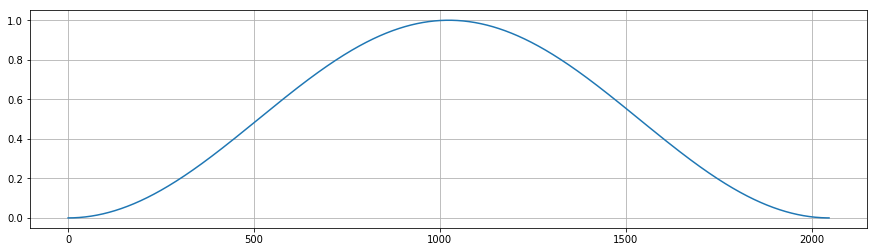

In [ ]:
window = get_window("hann", FFT_size, fftbins=True)
plt.figure(figsize=(15,4))
plt.plot(window)
plt.grid(True)

In [ ]:
print(len(window))
print(window)

2048
[0.00000000e+00 2.35309521e-06 9.41235870e-06 ... 2.11777240e-05
 9.41235870e-06 2.35309521e-06]


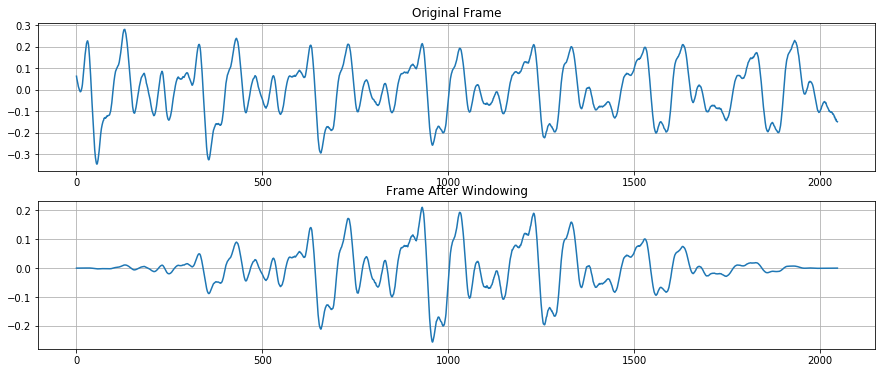

In [ ]:
audio_win = audio_framed * window

ind = 69
plt.figure(figsize=(15,6))
plt.subplot(2, 1, 1)
plt.plot(audio_framed[ind])
plt.title('Original Frame')
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(audio_win[ind])
plt.title('Frame After Windowing')
plt.grid(True)

In the plot above you can see the that both ends of the frame end on different places on the y axis. You can see that the window brought the edges of each frame closer to zero.

In [ ]:
print(audio_win.shape)

(408, 2048)


https://docs.scipy.org/doc/numpy/reference/generated/numpy.fft.fft.html

In [ ]:
audio_winT = np.transpose(audio_win)

#create a 2d-array to store the FFT coefficients
#note that the array has int(1 + FFT_size // 2) rows because we only want
#the coefficients in the frequency bands until Nyquist's frequency including w=0

audio_fft = np.empty((int(1 + FFT_size // 2), audio_winT.shape[1]), dtype=np.complex64, order='F')

for n in range(audio_fft.shape[1]):
    audio_fft[:, n] = fft.fft(audio_winT[:, n], axis=0)[:audio_fft.shape[0]]

audio_fft = np.transpose(audio_fft)

**Calculate signal power**


In [ ]:
audio_power = np.square(np.abs(audio_fft))
print(audio_power.shape)

(408, 1025)


**MEL-spaced filterbank**

Here we compute the MEL-spaced filterbank and then pass the framed audio through them. That will give us information about the power in each frequency band. The filters can be constructed for any frequency band but for our example we will look on the entire sampled band.

What special with the MEL-spaced filterbank is the spacing between the filters which grows exponentially with frequency. The filterbank can be made for any frequency band. Here we will compute the filterbank for the entire frequency band.


In [ ]:
freq_min = 0
freq_high = sample_rate / 2
mel_filter_num = 10

print("Minimum frequency: {0}".format(freq_min))
print("Maximum frequency: {0}".format(freq_high))

Minimum frequency: 0
Maximum frequency: 22050.0


In [ ]:
def freq_to_mel(freq):
    return 2595.0 * np.log10(1.0 + freq / 700.0)

def met_to_freq(mels):
    return 700.0 * (10.0**(mels / 2595.0) - 1.0)

**Compute filter points**

First we construct filter points that determines the start and stop of the filters. To do that we first convert the two filterbank edges to the MEL space. After that we construct a lineary spaced array between the two MEL frequencies. Then we convert the array to the frequency space

In [ ]:
def get_filter_points(fmin, fmax, mel_filter_num, FFT_size, sample_rate=44100):
    fmin_mel = freq_to_mel(fmin)
    fmax_mel = freq_to_mel(fmax)

    print("MEL min: {0}".format(fmin_mel))
    print("MEL max: {0}".format(fmax_mel))

    mels = np.linspace(fmin_mel, fmax_mel, num=mel_filter_num+2)
    freqs = met_to_freq(mels)

    #find exact/nearest frequency bands at which the filter point in Hz are present
    return np.floor((FFT_size + 1) / sample_rate * freqs).astype(int), freqs

In [ ]:
filter_points, mel_freqs = get_filter_points(freq_min, freq_high, mel_filter_num, FFT_size, sample_rate=44100)
filter_points

MEL min: 0.0
MEL max: 3923.337321740179


array([   0,   12,   28,   51,   82,  125,  184,  265,  376,  528,  737,
       1024])

In [ ]:
def get_filters(filter_points, FFT_size):
    #create a 2d array representing the filters
    #rows represent different filters
    #columns are the array representing each filter which is equal
    #to the fft coefficients in each window
    filters = np.zeros((len(filter_points)-2,int(FFT_size/2+1)))

    for n in range(len(filter_points)-2):
        filters[n, filter_points[n] : filter_points[n + 1]] = np.linspace(0, 1, filter_points[n + 1] - filter_points[n])
        filters[n, filter_points[n + 1] : filter_points[n + 2]] = np.linspace(1, 0, filter_points[n + 2] - filter_points[n + 1])

    return filters

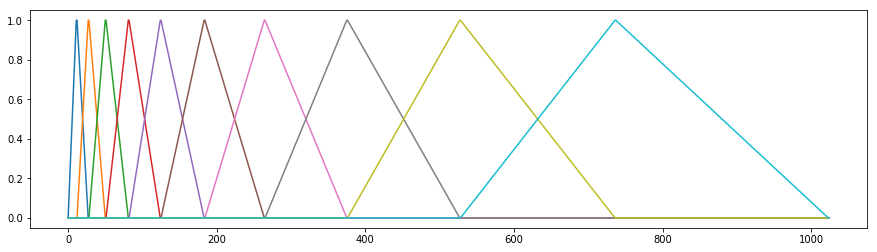

In [ ]:
filters = get_filters(filter_points, FFT_size)

plt.figure(figsize=(15,4))
for n in range(filters.shape[0]):
    plt.plot(filters[n])

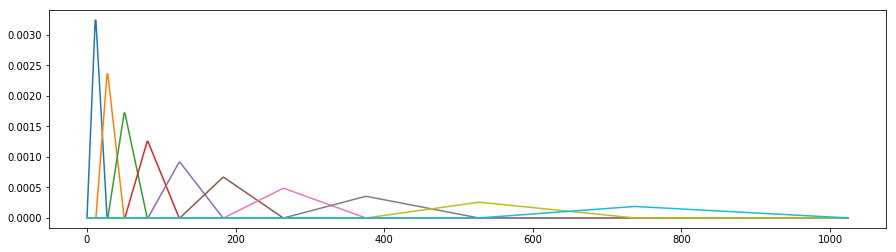

In [ ]:
# taken from the librosa library
enorm = 2.0 / (mel_freqs[2:mel_filter_num+2] - mel_freqs[:mel_filter_num])
filters *= enorm[:, np.newaxis]
plt.figure(figsize=(15,4))
for n in range(filters.shape[0]):
    plt.plot(filters[n])

**Filter the signal**

In [ ]:
print(filters.shape)
print(audio_power.shape)
print(filters[0,:20])

(10, 1025)
(408, 1025)
[0.         0.0002941  0.0005882  0.00088231 0.00117641 0.00147051
 0.00176461 0.00205872 0.00235282 0.00264692 0.00294102 0.00323513
 0.00323513 0.00301945 0.00280378 0.0025881  0.00237243 0.00215675
 0.00194108 0.0017254 ]


In [ ]:
audio_filtered = np.dot(filters, np.transpose(audio_power))
audio_log = 10.0 * np.log10(audio_filtered)
audio_log.shape

(10, 408)

Now we have a matrix represemting the audio power in all 10 filters in different time frames

**Generate the Cepstral Coefficents**
The final step in generating the MFCC is to use the Discrete Cosine Transform (DCT). We will use the DCT-III. This type of DCT will extract high frequency and low frequency changes in the the signal

In [ ]:
def dct(dct_filter_num, filter_len):
    basis = np.empty((dct_filter_num,filter_len))
    basis[0, :] = 1.0 / np.sqrt(filter_len)

    samples = np.arange(1, 2 * filter_len, 2) * np.pi / (2.0 * filter_len)

    for i in range(1, dct_filter_num):
        basis[i, :] = np.cos(i * samples) * np.sqrt(2.0 / filter_len)

    return basis

In [ ]:
dct_filter_num = 40

dct_filters = dct(dct_filter_num, mel_filter_num)

cepstral_coefficents = np.dot(dct_filters, audio_log)
cepstral_coefficents.shape

(40, 408)

**Reviewing Cepstral coefficents**

In [ ]:
cepstral_coefficents[:, 1]

array([-1.05265956e+02,  2.54547345e+01,  1.69770514e+01,  1.65043221e+01,
        1.14461346e+01,  9.42187125e+00,  6.76858240e+00,  4.53013178e+00,
        2.79579213e+00,  1.02334999e+00,  1.68074597e-13, -1.02334999e+00,
       -2.79579213e+00, -4.53013178e+00, -6.76858240e+00, -9.42187125e+00,
       -1.14461346e+01, -1.65043221e+01, -1.69770514e+01, -2.54547345e+01,
        1.48868543e+02, -2.54547345e+01, -1.69770514e+01, -1.65043221e+01,
       -1.14461346e+01, -9.42187125e+00, -6.76858240e+00, -4.53013178e+00,
       -2.79579213e+00, -1.02334999e+00, -4.38137157e-14,  1.02334999e+00,
        2.79579213e+00,  4.53013178e+00,  6.76858240e+00,  9.42187125e+00,
        1.14461346e+01,  1.65043221e+01,  1.69770514e+01,  2.54547345e+01])

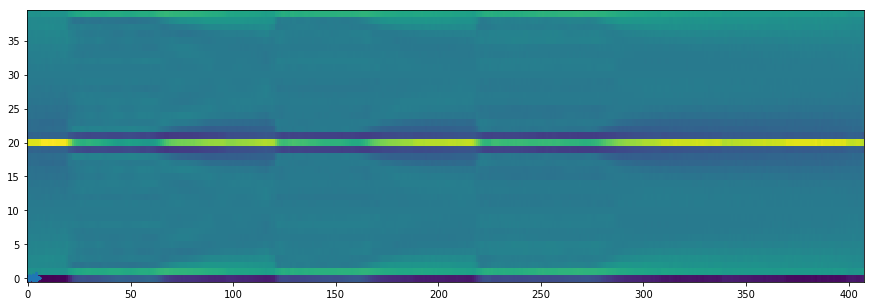

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(np.linspace(0, len(audio) / sample_rate, num=len(audio)), audio)
plt.imshow(cepstral_coefficents, aspect='auto', origin='lower');